In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df = pd.read_parquet("../../data/transformed/train_t02.parquet")

# Drop rows with missing coordinates
coords = df[["Latitude", "Longitude"]].dropna()
missing_pct = df[["Latitude", "Longitude"]].isna().mean()
print("Missing Lat/Lon %:\n", missing_pct)

# Fit KMeans — 20 clusters is a reasonable starting point for Chicago
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df.loc[coords.index, "geo_cluster"] = kmeans.fit_predict(coords)

# Rows with missing coords get cluster -1
df["geo_cluster"] = df["geo_cluster"].fillna(-1).astype(int)

print(df["geo_cluster"].value_counts().sort_index())

Missing Lat/Lon %:
 Latitude     0.003564
Longitude    0.003564
dtype: float64
geo_cluster
-1       391
 0     19487
 1      5165
 2      3062
 3      4235
 4      3966
 5      1394
 6      6749
 7      3660
 8      4946
 9      4095
 10     7807
 11     8369
 12     5779
 13     2858
 14     4365
 15     2759
 16     4523
 17     6486
 18     3956
 19     5641
Name: count, dtype: int64


In [22]:
cluster_fail_rate = (
    df[df["geo_cluster"] != -1]
    .groupby("geo_cluster")["Results"]
    .mean()
    .rename("cluster_fail_rate")
    .sort_values(ascending=False)
)

print(cluster_fail_rate)
print(f"\nFail rate range across clusters: {cluster_fail_rate.min():.3f} – {cluster_fail_rate.max():.3f}")
print(f"Std dev: {cluster_fail_rate.std():.3f}")

geo_cluster
9     0.373138
18    0.369060
8     0.342499
13    0.339398
11    0.331581
19    0.323701
6     0.317232
4     0.309632
3     0.306257
10    0.302165
12    0.300225
14    0.289347
17    0.287388
16    0.277913
1     0.258858
0     0.257402
2     0.251470
15    0.250816
7     0.218306
5     0.200861
Name: cluster_fail_rate, dtype: float64

Fail rate range across clusters: 0.201 – 0.373
Std dev: 0.046


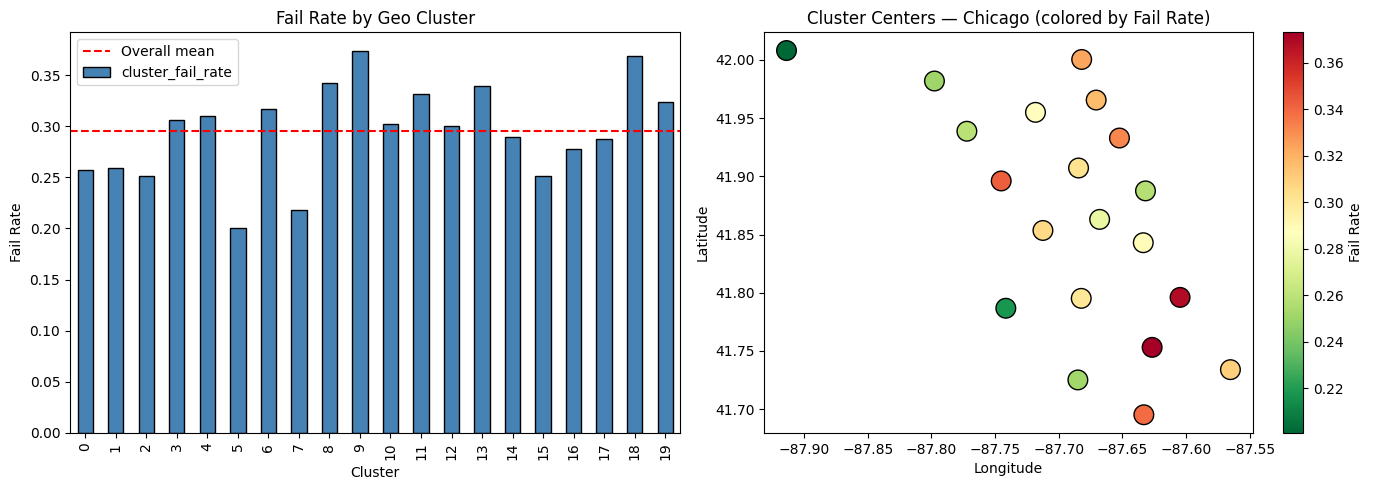

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: fail rate per cluster
cluster_fail_rate.sort_index().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Fail Rate by Geo Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Fail Rate")
axes[0].axhline(df["Results"].mean(), color="red", linestyle="--", label="Overall mean")
axes[0].legend()

# Scatter: clusters on map colored by fail rate
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=["Latitude", "Longitude"])
cluster_centers["fail_rate"] = cluster_fail_rate.reindex(cluster_centers.index).values

sc = axes[1].scatter(
    cluster_centers["Longitude"], cluster_centers["Latitude"],
    c=cluster_centers["fail_rate"], cmap="RdYlGn_r", s=200, edgecolors="black"
)
plt.colorbar(sc, ax=axes[1], label="Fail Rate")
axes[1].set_title("Cluster Centers — Chicago (colored by Fail Rate)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import f_oneway

groups = [
    df[df["geo_cluster"] == c]["Results"].values
    for c in df["geo_cluster"].unique() if c != -1
]

f_stat, p_value = f_oneway(*groups)
print(f"One-way ANOVA: F={f_stat:.2f}, p={p_value:.4f}")
print("Conclusion:", "Geo cluster is statistically significant" if p_value < 0.05 else "No significant difference")

One-way ANOVA: F=42.22, p=0.0000
Conclusion: Geo cluster is statistically significant


## LICENSE DESCRIPTION

In [25]:
print("Unique values:", df["LICENSE DESCRIPTION"].nunique())
print("\nTop 20 by frequency:")
print(df["LICENSE DESCRIPTION"].value_counts().head(20))
print("\nMissing:", df["LICENSE DESCRIPTION"].isna().sum())

Unique values: 62

Top 20 by frequency:
LICENSE DESCRIPTION
Retail Food Establishment                        90052
Consumption on Premises - Incidental Activity     2132
Children's Services Facility License              1943
Day Care Center 2 - 6 Years                       1719
Limited Business License                          1586
Day Care Center Under 2 and 2 - 6 Years            907
Package Goods                                      817
Tavern                                             595
Day Care Center Under 2 Years                      493
Wholesale Food Establishment                       444
Long-Term Care Facility                            409
Mobile Food License                                404
Mobile Food Dispenser                              394
Regulated Business License                         354
Tobacco                                            256
Caterer's Liquor License                           199
Shared Kitchen User (Long Term)                    178
Wrigl

In [14]:
# Compute fail rate per LICENSE DESCRIPTION on train set only
desc_fail_rate = (
    df.groupby("LICENSE DESCRIPTION")["Results"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "desc_fail_rate", "count": "desc_count"})
)

# Only keep descriptions with enough samples (avoid noise from rare ones)
min_samples = 30
desc_fail_rate.loc[desc_fail_rate["desc_count"] < min_samples, "desc_fail_rate"] = np.nan

df["license_desc_encoded"] = df["LICENSE DESCRIPTION"].map(desc_fail_rate["desc_fail_rate"])
df["license_desc_encoded"] = df["license_desc_encoded"].fillna(df["Results"].mean())  # fallback to global mean

print(f"\nEncoded — nulls remaining: {df['license_desc_encoded'].isna().sum()}")
print(df["license_desc_encoded"].describe())


Encoded — nulls remaining: 0
count    109693.000000
mean          0.296263
std           0.025981
min           0.000000
25%           0.301803
50%           0.301803
75%           0.301803
max           0.385135
Name: license_desc_encoded, dtype: float64


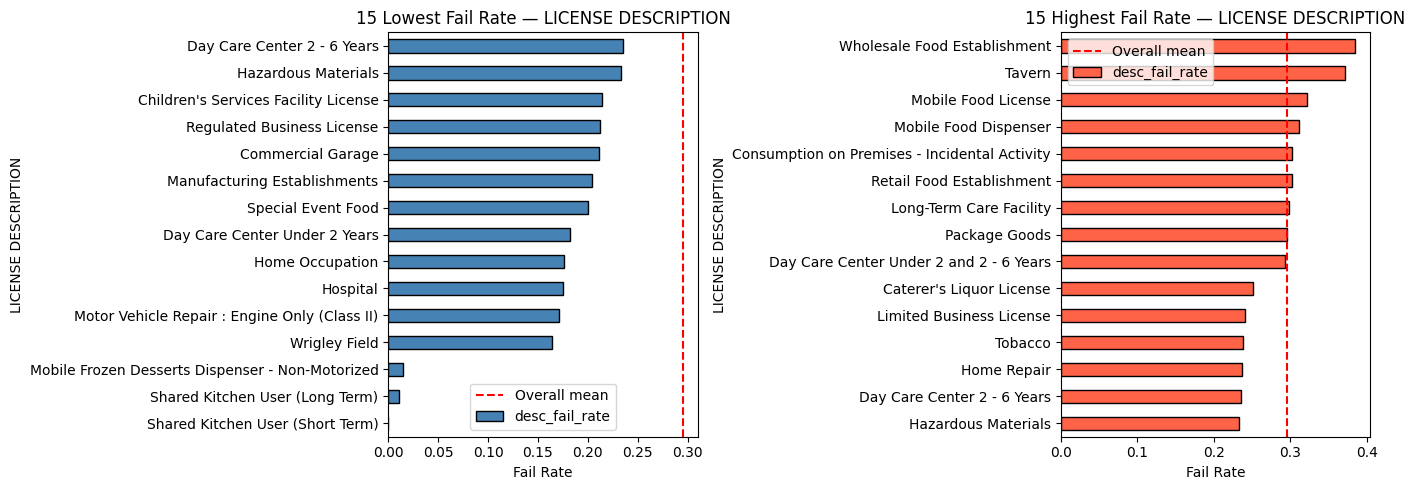

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top/bottom 15 descriptions by fail rate (with enough samples)
top_desc = (
    desc_fail_rate[desc_fail_rate["desc_count"] >= min_samples]["desc_fail_rate"]
    .sort_values()
)

top_desc.head(15).plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("15 Lowest Fail Rate — LICENSE DESCRIPTION")
axes[0].set_xlabel("Fail Rate")
axes[0].axvline(df["Results"].mean(), color="red", linestyle="--", label="Overall mean")
axes[0].legend()

top_desc.tail(15).plot(kind="barh", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("15 Highest Fail Rate — LICENSE DESCRIPTION")
axes[1].set_xlabel("Fail Rate")
axes[1].axvline(df["Results"].mean(), color="red", linestyle="--", label="Overall mean")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import f_oneway

groups = [
    df[df["LICENSE DESCRIPTION"] == d]["Results"].values
    for d in desc_fail_rate[desc_fail_rate["desc_count"] >= min_samples].index
]

f_stat, p_value = f_oneway(*groups)
print(f"One-way ANOVA: F={f_stat:.2f}, p={p_value:.4f}")
print(f"Fail rate std across descriptions: {desc_fail_rate['desc_fail_rate'].std():.3f}")
print("Conclusion:", "Statistically significant signal" if p_value < 0.05 else "No significant difference")

One-way ANOVA: F=13.19, p=0.0000
Fail rate std across descriptions: 0.096
Conclusion: Statistically significant signal


## DATE ISSUED

In [41]:
df = pd.read_csv("../../data/raw/merged_inspections_licenses_inner.csv")

In [42]:
print(df[["DATE ISSUED", "APPLICATION CREATED DATE", "Inspection Date"]].dtypes)
print(df[["DATE ISSUED", "APPLICATION CREATED DATE"]].isna().mean())
print(df[["DATE ISSUED", "APPLICATION CREATED DATE"]].head(5))

DATE ISSUED                 object
APPLICATION CREATED DATE    object
Inspection Date             object
dtype: object
DATE ISSUED                 0.049272
APPLICATION CREATED DATE    0.905571
dtype: float64
  DATE ISSUED APPLICATION CREATED DATE
0  2025-04-02                      NaN
1  2024-09-11                      NaN
2  2020-01-06               11/04/2019
3  2026-01-08                      NaN
4  2025-10-23                      NaN


In [43]:
# Parse dates if not already datetime
for col in ["DATE ISSUED", "APPLICATION CREATED DATE", "Inspection Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Days from license issuance to inspection date = business tenure at time of inspection
df["business_tenure_days"] = (df["Inspection Date"] - df["DATE ISSUED"]).dt.days

# Fallback: use APPLICATION CREATED DATE where DATE ISSUED is null
mask = df["business_tenure_days"].isna()
df.loc[mask, "business_tenure_days"] = (
    df.loc[mask, "Inspection Date"] - df.loc[mask, "APPLICATION CREATED DATE"]
).dt.days

# Sanity check — drop negatives (data errors)
print("Negative tenure rows:", (df["business_tenure_days"] < 0).sum())
df.loc[df["business_tenure_days"] < 0, "business_tenure_days"] = np.nan

print(df["business_tenure_days"].describe())
print("Missing:", df["business_tenure_days"].isna().sum())

Negative tenure rows: 147147
count    39980.000000
mean       876.939645
std       1073.354579
min          0.000000
25%        244.000000
50%        488.000000
75%        930.000000
max       6496.000000
Name: business_tenure_days, dtype: float64
Missing: 156845


In [44]:
def compute_violation_count(df):
    df["violation_count"] = (
        df["Violations"]
        .fillna("")
        .apply(lambda x: len([v for v in x.split("|") if v.strip()]))
    )
    return df

def binarize_results(df):
    df["Results"] = df["Results"].str.strip()
    
    pwc_mask = df["Results"].str.lower() == "pass w/ conditions"
    df.loc[pwc_mask, "Results"] = (df.loc[pwc_mask, "violation_count"] >= 4).astype(int)
    
    mapping = {"Pass": 0, "Fail": 1}
    df["Results"] = df["Results"].map(mapping).combine_first(df["Results"])
    
    df = df[df["Results"].isin([0, 1])].copy()
    df["Results"] = df["Results"].astype(int)
    
    return df

# Usage — call compute_violation_count first, always
df = compute_violation_count(df)
df = binarize_results(df)

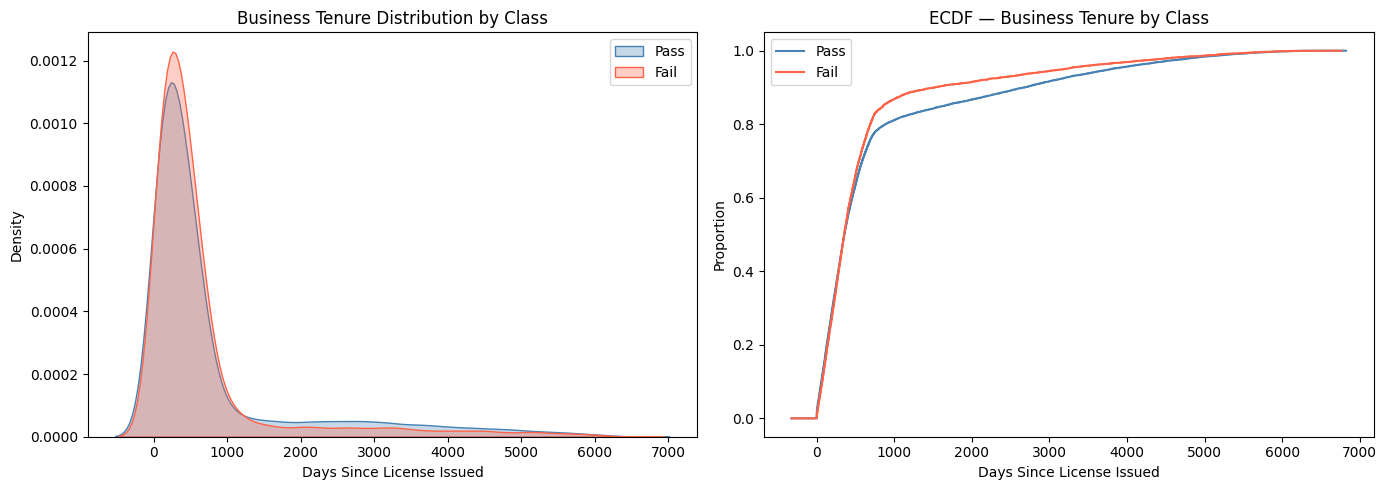

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE — continuous distribution by class
for label, color in [(0, "steelblue"), (1, "tomato")]:
    sns.kdeplot(
        df[df["Results"] == label]["business_tenure_days"].dropna(),
        ax=axes[0], label=["Pass", "Fail"][label],
        color=color, fill=True, alpha=0.3
    )
axes[0].set_title("Business Tenure Distribution by Class")
axes[0].set_xlabel("Days Since License Issued")
axes[0].legend()

from scipy.stats import ecdf

ax = axes[1]
for label, color, name in [(0, "steelblue", "Pass"), (1, "tomato", "Fail")]:
    subset = df[df["Results"] == label]["business_tenure_days"].dropna()
    res = ecdf(subset)
    res.cdf.plot(ax=ax, color=color, label=name)

ax.set_title("ECDF — Business Tenure by Class")
ax.set_xlabel("Days Since License Issued")
ax.set_ylabel("Proportion")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pointbiserialr, mannwhitneyu

# Point-biserial correlation (continuous vs binary target)
valid = df[["business_tenure_days", "Results"]].dropna()
corr, p_corr = pointbiserialr(valid["Results"], valid["business_tenure_days"])
print(f"Point-biserial correlation: {corr:.4f}, p={p_corr:.4f}")

# Mann-Whitney U (non-parametric — better for skewed tenure distributions)
pass_tenure = valid[valid["Results"] == 0]["business_tenure_days"]
fail_tenure = valid[valid["Results"] == 1]["business_tenure_days"]
u_stat, p_mw = mannwhitneyu(pass_tenure, fail_tenure, alternative="two-sided")
print(f"Mann-Whitney U: stat={u_stat:.0f}, p={p_mw:.4f}")
print("Conclusion:", "Significant signal" if p_mw < 0.05 else "No significant difference")
print(f"\nMedian tenure — Pass: {pass_tenure.median():.0f} days | Fail: {fail_tenure.median():.0f} days")

Point-biserial correlation: -0.0620, p=0.0000
Mann-Whitney U: stat=65178464, p=0.0205
Conclusion: Significant signal

Median tenure — Pass: 357 days | Fail: 354 days
